# (12) MNIST: (64/128, 32.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>

Lienar decoder + MNIST works?

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## MNIST

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'MNIST')

cfg_vae['seq_len'] = 64
cfg_tr['kl_beta'] = 32.0

# cfg_tr['lr'] = 0.001
# cfg_tr['epochs'] = 400
cfg_tr['chkpt_freq'] = 1

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  403.2 K   |
|     ———     |    ———     |
|    layer    |  403.2 K   |
+-------------+------------+

poisson_MNIST_t-64_z-[512]_u-10,du-10_<grad|lin>
b100-ep400-lr(0.002)_beta(32:0.1)_temp(0.01:0.5)_gr(3000)_(2025_03_16,09:08)

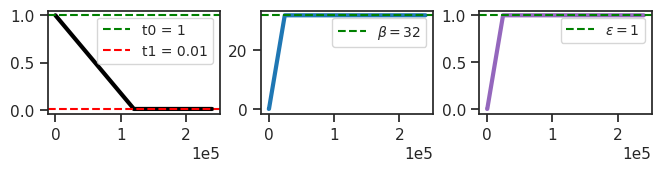

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

240000

In [6]:
tr.train()

epoch # 2, avg loss: 0.733:   0%|            | 2/400 [03:17<10:56:16, 98.94s/it]

KeyboardInterrupt



In [7]:
### Was: (64, 32.0)

epoch # 400, avg loss: -376.250: 100%|██████| 400/400 [9:35:14<00:00, 86.29s/it]


In [5]:
### Was: (32, 20.0)

epoch # 400, avg loss: -342.811: 100%|██████| 400/400 [3:44:41<00:00, 33.70s/it]


In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0304], device='cuda:1', grad_fn=<ExpBackward0>),)

## Load & Eval

```(64, 64.0)```

In [3]:
a = 'poisson_MNIST_t-64_z-[512]_u-10,du-10_<grad|lin>'
b = 'b100-ep400-lr(0.002)_beta(64:0.1)_temp(0.01:0.5)_gr(3000)_(2025_03_16,15:44)'
tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

400

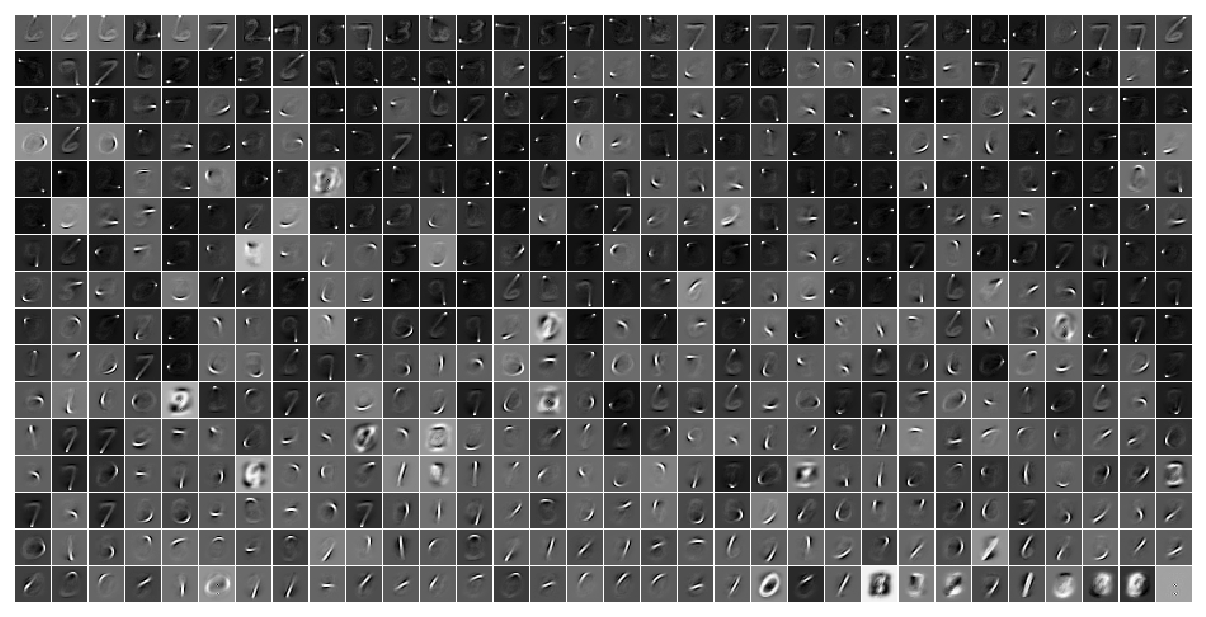

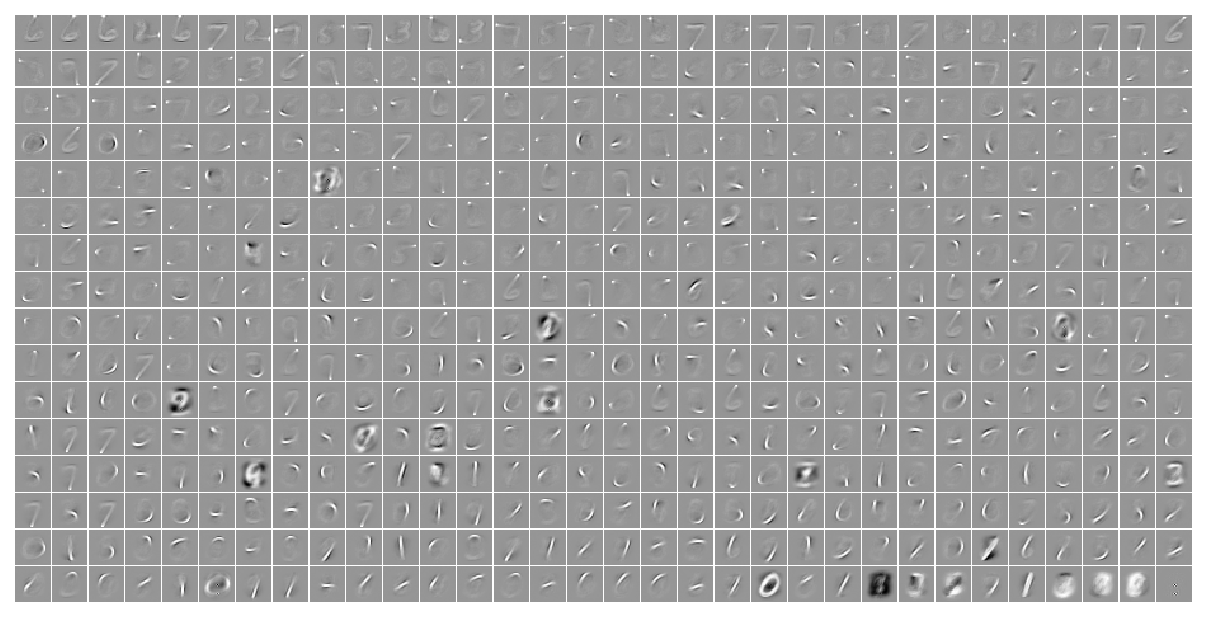

In [4]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

100%|███████████████████████████████████| 5/5 [01:34<00:00, 18.82s/it]


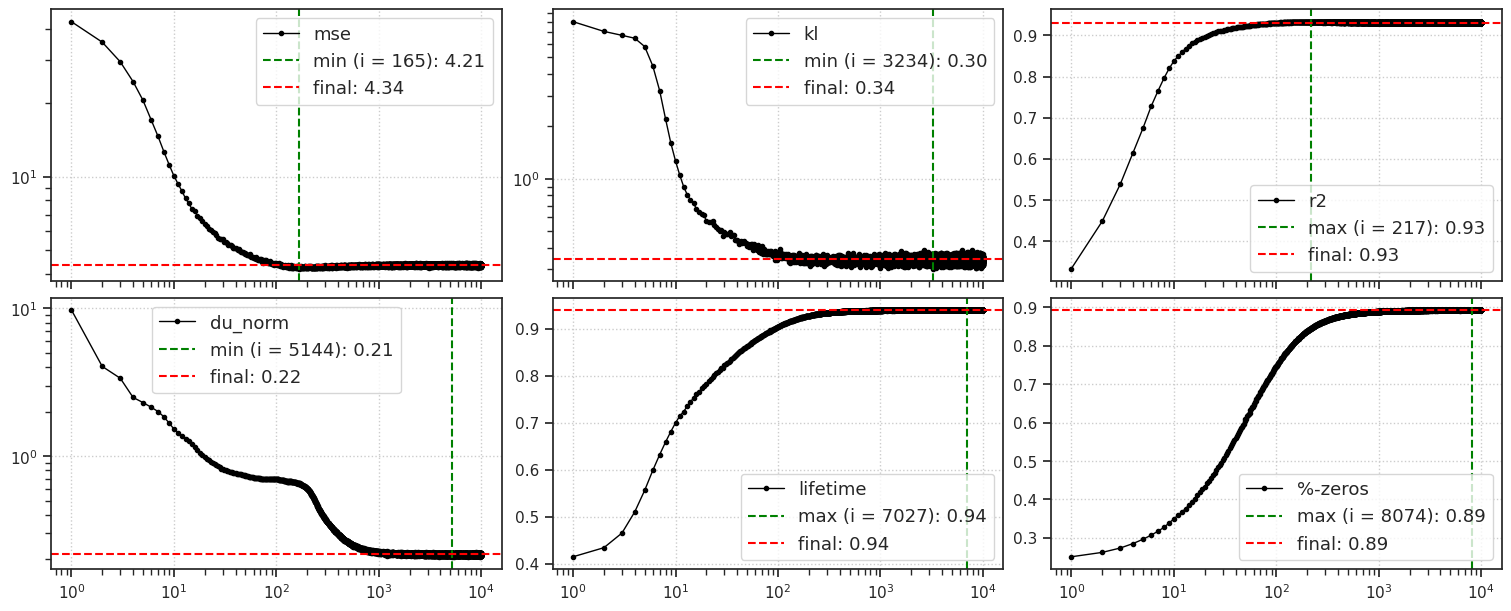

CPU times: user 1min 46s, sys: 3.84 s, total: 1min 50s
Wall time: 1min 51s


In [5]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=5,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

### clf

In [7]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=100,
    data_batch_sz=5000,
    verbose=True,
)
results = {
    name: tr.xtract_ftr(name, **kws)
    for name in ['trn', 'vld']
}

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.30s/it]


In [8]:
results['trn']['mse'][-1], results['vld']['mse'][-1]

(4.3811436, 4.413514)

In [9]:
list(results['vld'])

['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [10]:
lamb = {k: np.exp(d['state'][:, -1]) for k, d in results.items()}

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [12]:
clf = LogisticRegression(C=1.0).fit(
    lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))

pred = clf.predict(lamb['vld'])
true = tonp(tr.dl_vld.dataset.tensors[1])

In [13]:
report = classification_report(true, pred, output_dict=True)
report['accuracy']

0.9672

## Load & Eval

```(256, 128.0)``` -- was incomplete

In [3]:
a = 'poisson_MNIST_t-256_z-[512]_u-10,du-10_<grad|lin>'
b = 'b100-ep400-lr(0.002)_beta(128:0.1)_temp(0.01:0.5)_gr(2000)_(2025_03_14,16:18)'
tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

180

In [4]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0155], device='cuda:1', grad_fn=<ExpBackward0>),)

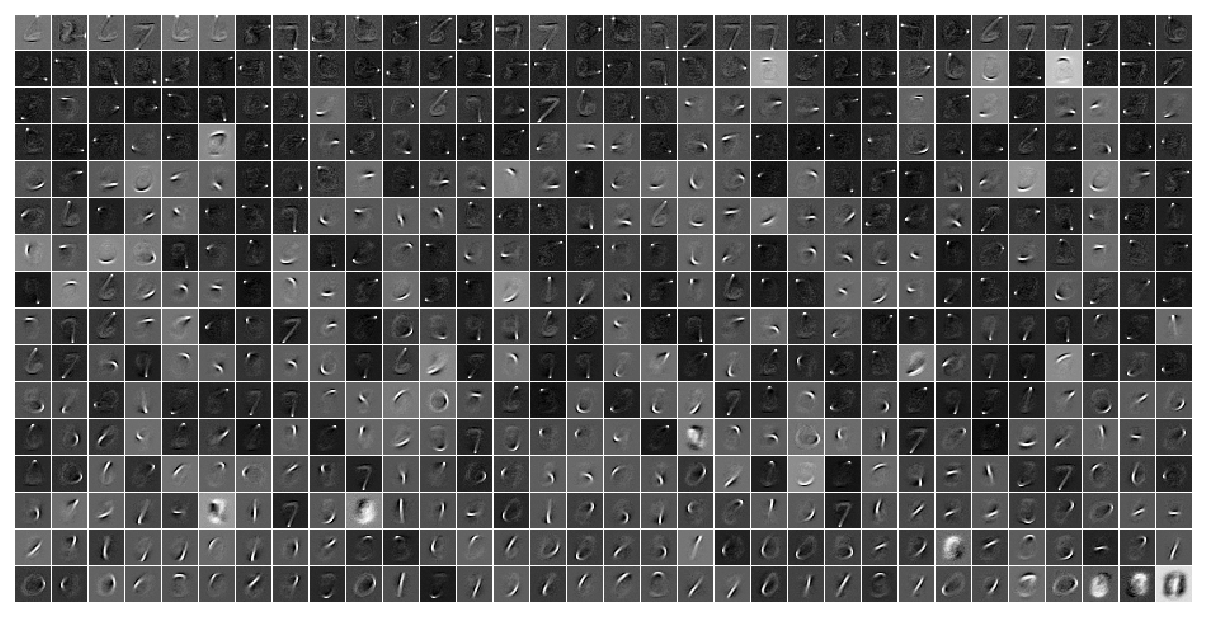

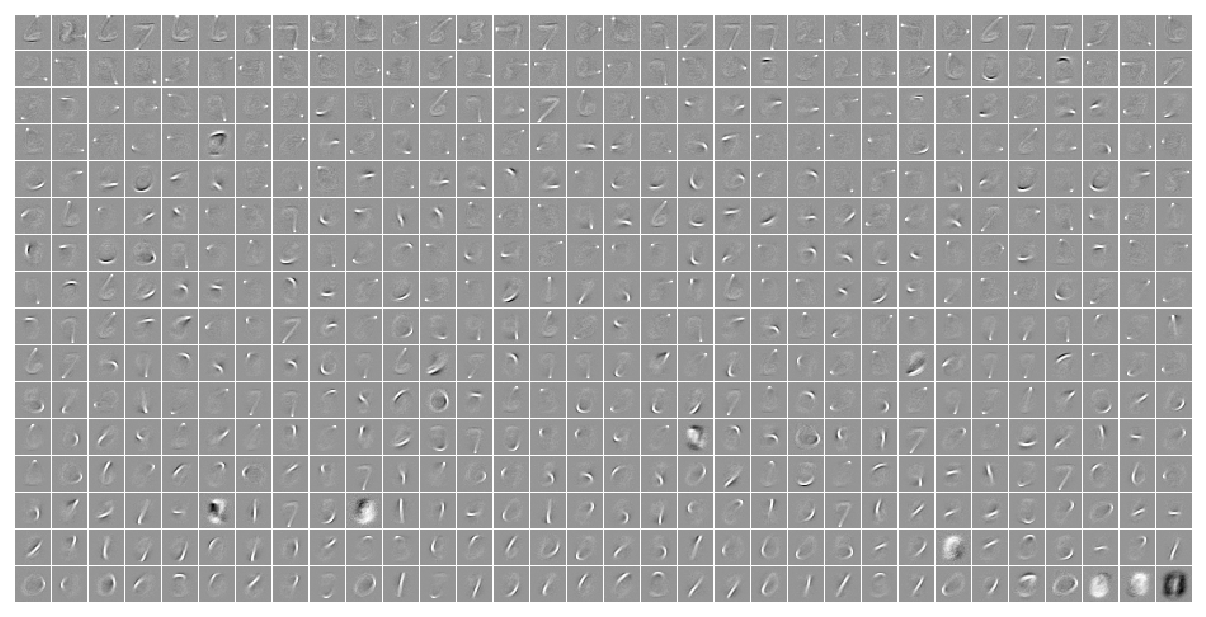

In [5]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

100%|███████████████████████████████████| 2/2 [00:38<00:00, 19.04s/it]


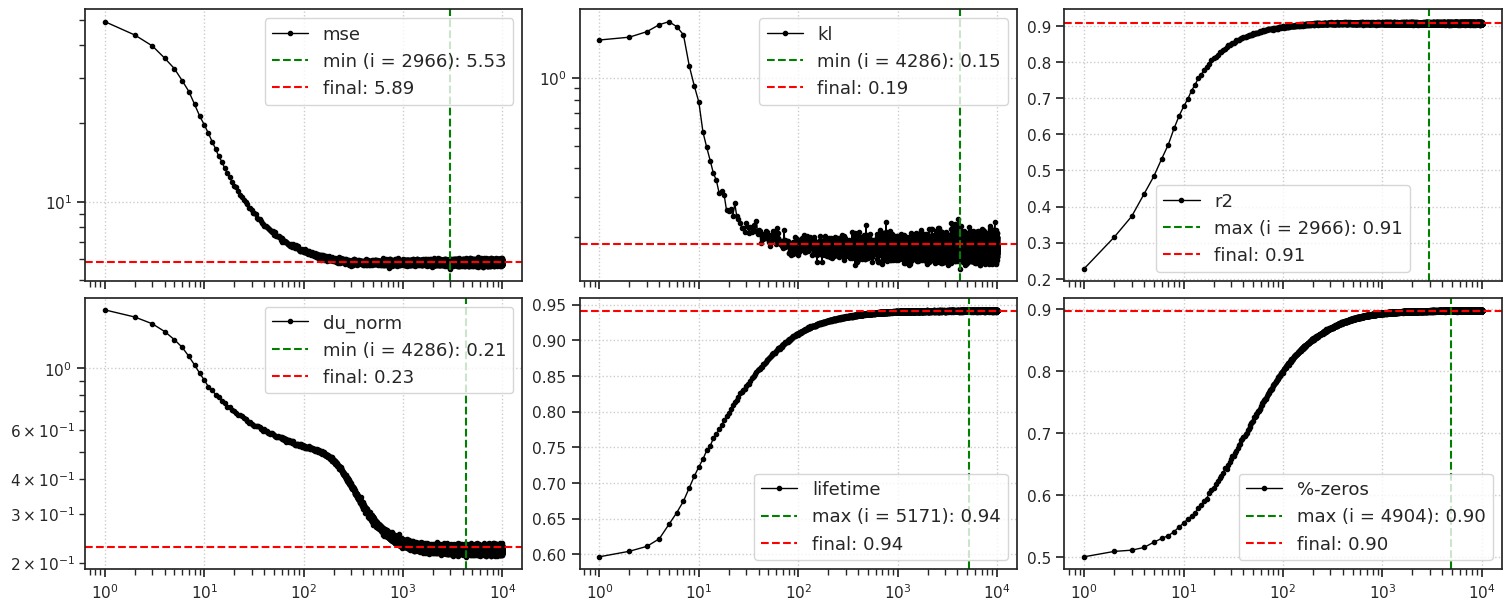

CPU times: user 42.8 s, sys: 1.61 s, total: 44.4 s
Wall time: 45.7 s


In [6]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

### clf

In [7]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=100,
    data_batch_sz=5000,
    verbose=True,
)
results = {
    name: tr.xtract_ftr(name, **kws)
    for name in ['trn', 'vld']
}

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.09s/it]


In [8]:
results['trn']['mse'][-1], results['vld']['mse'][-1]

(6.0552735, 6.0818715)

In [9]:
list(results['vld'])

['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [10]:
lamb = {k: np.exp(d['state'][:, -1]) for k, d in results.items()}

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [12]:
clf = LogisticRegression(C=1.0).fit(
    lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))

pred = clf.predict(lamb['vld'])
true = tonp(tr.dl_vld.dataset.tensors[1])

In [14]:
report = classification_report(true, pred, output_dict=True)
report['accuracy']

0.9605

## Load & Eval

```(64, 32.0)```

In [5]:
a = 'poisson_MNIST_t-64_z-[512]_u-10,du-10_<grad|lin>'
b = 'b100-ep400-lr(0.002)_beta(32:0.1)_temp(0.01:0.5)_gr(1000)_(2025_03_13,09:24)'
tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

400

In [6]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0601], device='cuda:1', grad_fn=<ExpBackward0>),)

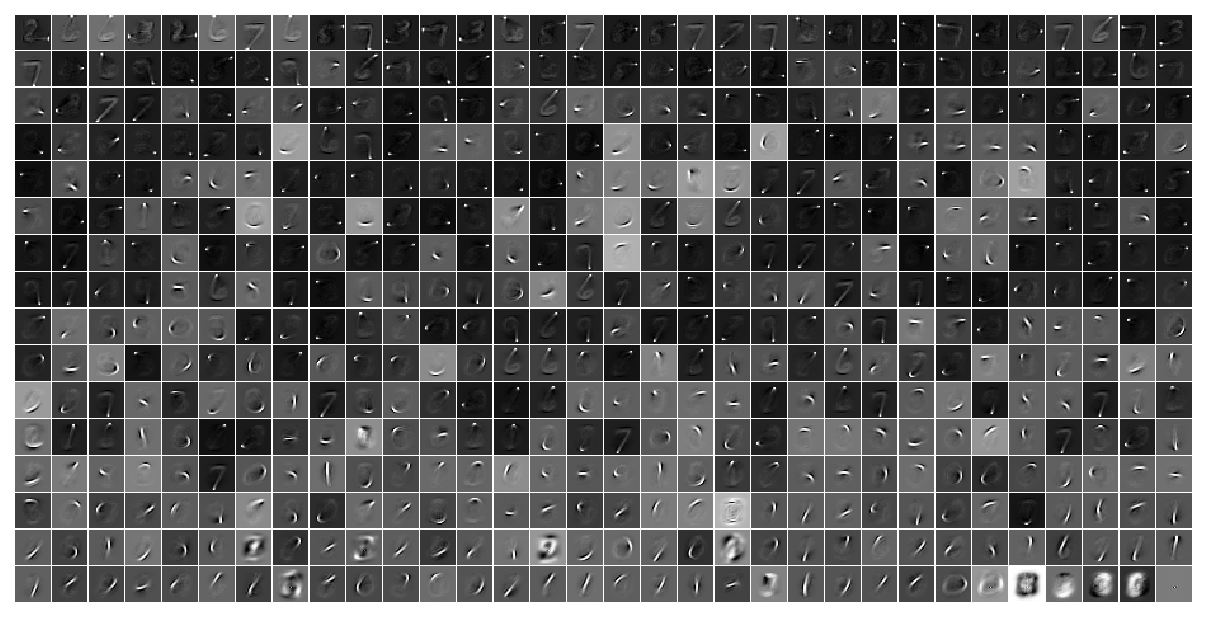

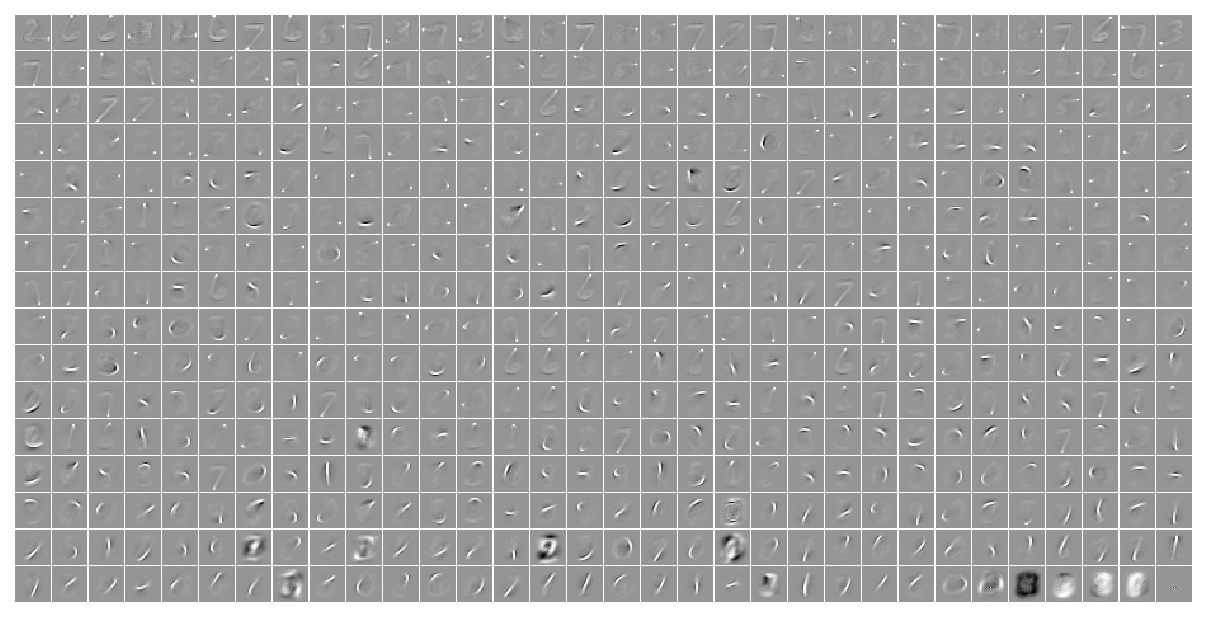

In [7]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

100%|███████████████████████████████████| 2/2 [00:38<00:00, 19.04s/it]


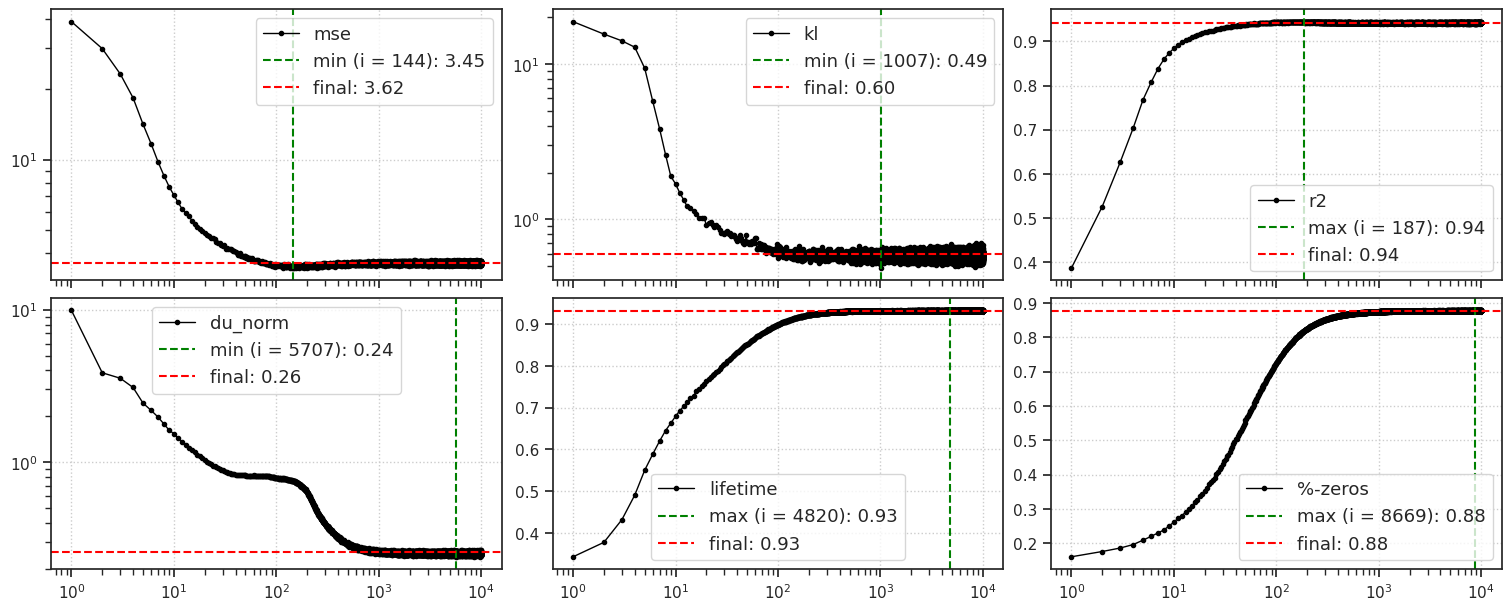

CPU times: user 43.1 s, sys: 1.54 s, total: 44.7 s
Wall time: 45.9 s


In [8]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

### clf

In [9]:
kws = dict(
    seq_total=1000,
    seq_batch_sz=100,
    data_batch_sz=5000,
    verbose=True,
)
results = {
    name: tr.xtract_ftr(name, **kws)
    for name in ['trn', 'vld']
}

100%|███████████████████████████████████| 2/2 [00:04<00:00,  2.40s/it]


In [13]:
results['trn']['mse'][-1], results['vld']['mse'][-1]

(3.6792479, 3.7151468)

In [14]:
list(results['vld'])

['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [55]:
lamb = {k: np.exp(d['state'][:, -1]) for k, d in results.items()}

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [57]:
clf = LogisticRegression(C=1.0).fit(
    lamb['trn'], tonp(tr.dl_trn.dataset.tensors[1]))

pred = clf.predict(lamb['vld'])
true = tonp(tr.dl_vld.dataset.tensors[1])

In [58]:
report = classification_report(true, pred, output_dict=True)
report['accuracy']

0.9662

## Previous fit

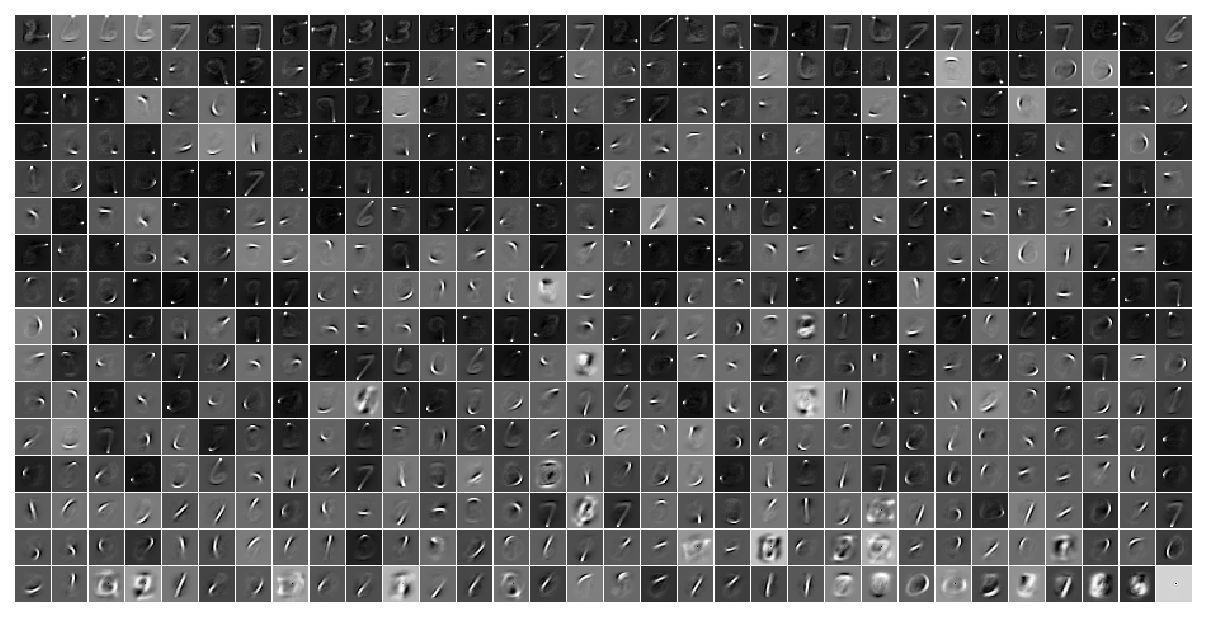

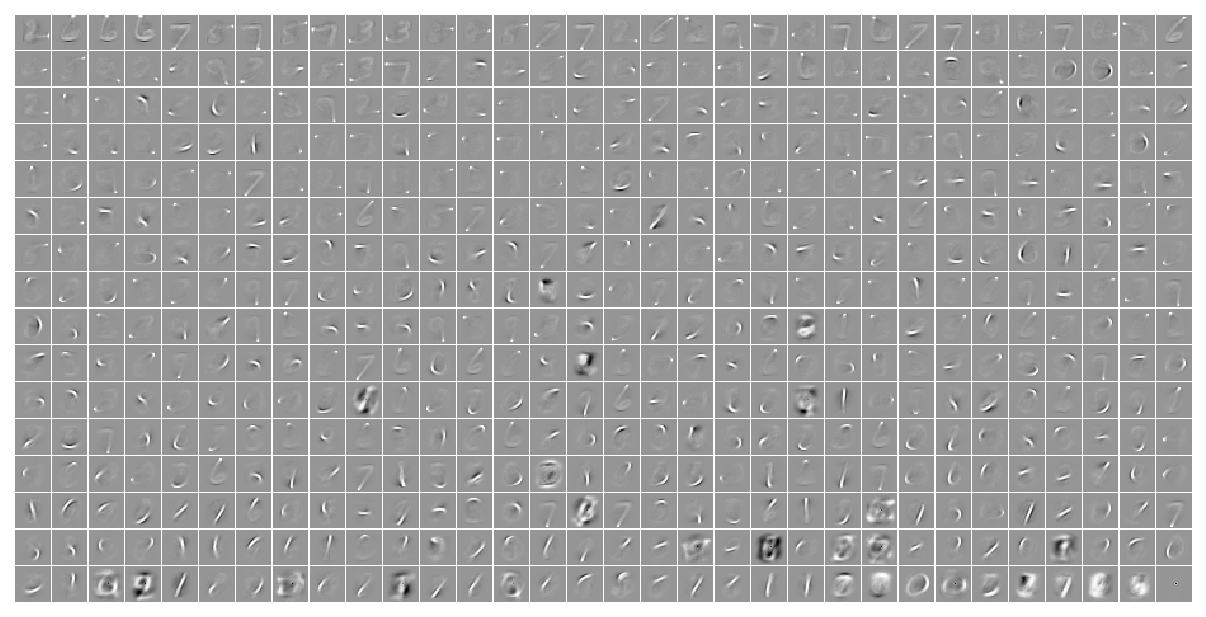

In [7]:
### Was: (32, 20.0)

100%|███████████████████████████████████| 2/2 [00:38<00:00, 19.31s/it]


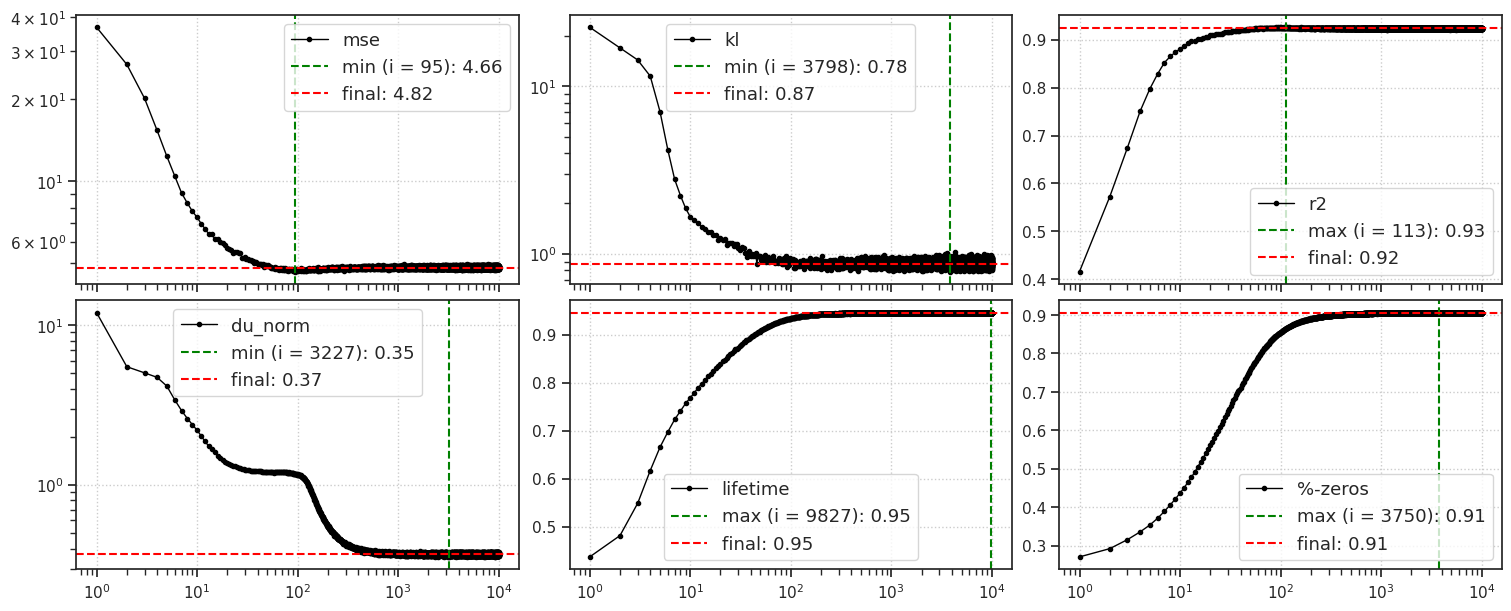

CPU times: user 49.8 s, sys: 3.28 s, total: 53.1 s
Wall time: 53.1 s


In [8]:
### Was: (32, 20.0)